## Setup + učitavanje podataka

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    confusion_matrix,
    classification_report,
    accuracy_score,
    mean_squared_error,
    r2_score,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)

from sklearn.linear_model import LinearRegression, LogisticRegression


In [2]:
print("Files in /content:", os.listdir("/content")[:20])

DATA_PATH = "/content/creditcard.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Ne mogu da nađem fajl: {DATA_PATH}. Proveri upload u Colab Files panelu.")

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()


Files in /content: ['.config', 'creditcard.csv', 'sample_data']
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Deskriptivna analiza + osnovne provere

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## Provera missing vrednosti i duplikata

In [5]:
print("Missing values per column:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Duplicate rows: 1081


In [6]:
df["Class"].value_counts()


,count
Class,
0,284315
1,492


## Uzorkovanje, sample, odvajanje X od y

In [7]:
RANDOM_STATE = 42
SAMPLE_SIZE = 30000

df_sample = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)

print("Sample shape:", df_sample.shape)
df_sample.head()


Sample shape: (30000, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,41505.0,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,-8.507059,...,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,364.19,1
1,44261.0,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,0.899746,...,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,520.12,0
2,35484.0,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,-0.971747,...,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,31.00,0
3,167123.0,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,-0.484715,...,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,1.50,0
4,168473.0,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,0.363241,...,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,0.89,0


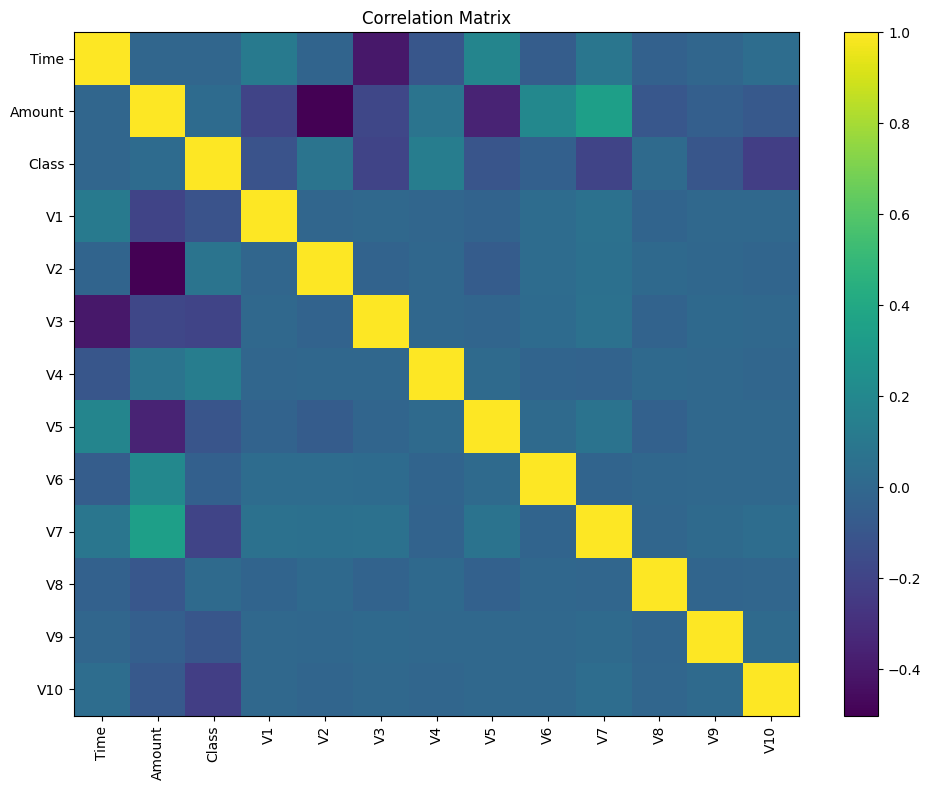

In [8]:
cols = ["Time", "Amount", "Class"] + [f"V{i}" for i in range(1, 11)]

corr_matrix = df_sample[cols].corr()

plt.figure(figsize=(10,8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()

plt.xticks(range(len(cols)), cols, rotation=90)
plt.yticks(range(len(cols)), cols)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()

In [9]:
X = df_sample.drop(columns=["Class"])
y = df_sample["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (30000, 30)
y shape: (30000,)


## Outlieri: Amount i Time (distribucije)

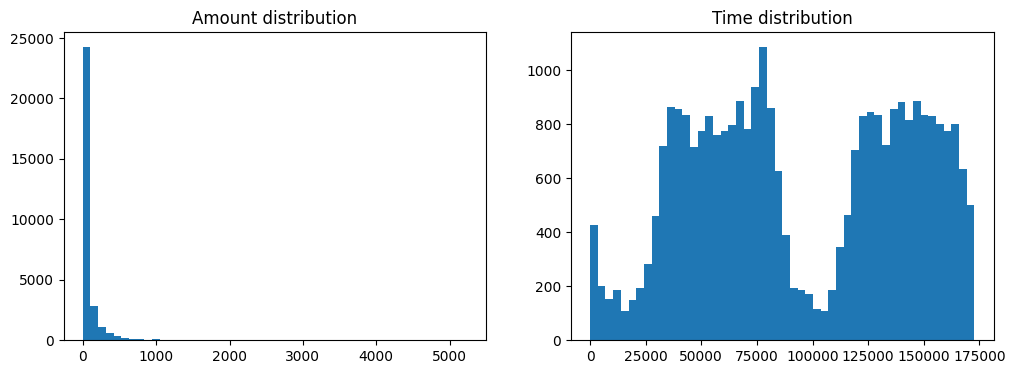

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df_sample["Amount"], bins=50)
ax[0].set_title("Amount distribution")

ax[1].hist(df_sample["Time"], bins=50)
ax[1].set_title("Time distribution")

plt.show()


## Detekcija i obrada outliera: Isolation Forest

In [11]:
iso = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42
)

outlier_flag = iso.fit_predict(X)
is_outlier = (outlier_flag == -1)

print("Detected outliers:", is_outlier.sum())
print("Percentage:", is_outlier.mean() * 100)


Detected outliers: 300
Percentage: 1.0


In [12]:
X_inliers = X.loc[~is_outlier].reset_index(drop=True)
y_inliers = y.loc[~is_outlier].reset_index(drop=True)

print("Before:", X.shape)
print("After :", X_inliers.shape)


Before: (30000, 30)
After : (29700, 30)


## Skaliranje podataka: StandardScaler vs RobustScaler

In [13]:
scaler_std = StandardScaler()
scaler_rob = RobustScaler()

X_std = scaler_std.fit_transform(X_inliers)
X_rob = scaler_rob.fit_transform(X_inliers)

print("X_std:", X_std.shape, "X_rob:", X_rob.shape)


X_std: (29700, 30) X_rob: (29700, 30)


## Redukcija dimenzionalnosti: PCA (izbor broja komponenti)

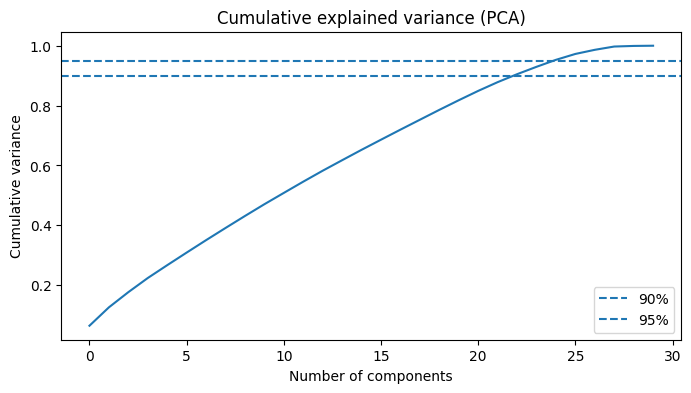

Components for 90%: 23
Components for 95%: 25


In [14]:
pca_full = PCA(n_components=None, random_state=42)
pca_full.fit(X_std)

explained = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(explained)
plt.axhline(0.90, linestyle="--", label="90%")
plt.axhline(0.95, linestyle="--", label="95%")
plt.legend()
plt.title("Cumulative explained variance (PCA)")
plt.xlabel("Number of components")
plt.ylabel("Cumulative variance")
plt.show()

n90 = np.argmax(explained >= 0.90) + 1
n95 = np.argmax(explained >= 0.95) + 1

print("Components for 90%:", n90)
print("Components for 95%:", n95)


In [15]:
N_COMPONENTS = min(n95, X_std.shape[1])
pca = PCA(n_components=N_COMPONENTS, random_state=42)

X_std_pca = pca.fit_transform(X_std)
X_rob_pca = pca.fit_transform(X_rob)

print("X_std_pca:", X_std_pca.shape, "X_rob_pca:", X_rob_pca.shape)


X_std_pca: (29700, 25) X_rob_pca: (29700, 25)


## Pomoćne funkcije za evaluaciju klastera

In [16]:
def clustering_metrics(X, labels):
    """Vraća (silhouette, davies_bouldin, calinski_harabasz, n_clusters, n_noise).
    Ako DBSCAN ima noise (-1), metričke računa samo na non-noise tačkama.
    """
    labels = np.asarray(labels)
    n_noise = int(np.sum(labels == -1))
    unique = set(labels)
    n_clusters = len(unique) - (1 if -1 in unique else 0)

    if n_clusters < 2:
        return np.nan, np.nan, np.nan, n_clusters, n_noise

    if -1 in unique:
        mask = labels != -1
        X_use = X[mask]
        labels_use = labels[mask]
    else:
        X_use = X
        labels_use = labels

    sil = silhouette_score(X_use, labels_use)
    dbi = davies_bouldin_score(X_use, labels_use)
    chi = calinski_harabasz_score(X_use, labels_use)
    return sil, dbi, chi, n_clusters, n_noise


## KMeans klasterizacija (izbor k + evaluacija)

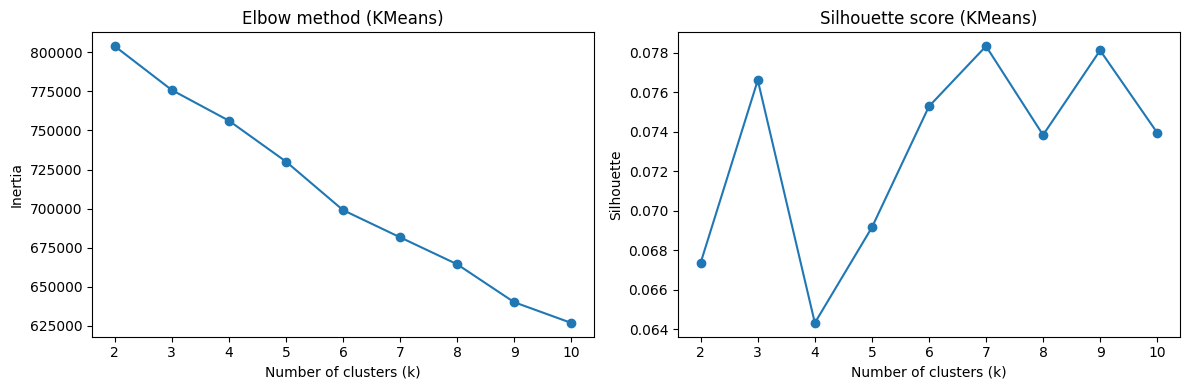

Best k according to silhouette: 7


In [17]:
k_values = range(2, 11)
inertias = []
silhouettes = []

for k in k_values:
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    labels = km.fit_predict(X_std_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_std_pca, labels))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(list(k_values), inertias, marker="o")
plt.title("Elbow method (KMeans)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")

plt.subplot(1, 2, 2)
plt.plot(list(k_values), silhouettes, marker="o")
plt.title("Silhouette score (KMeans)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette")

plt.tight_layout()
plt.show()

best_k_kmeans = int(list(k_values)[int(np.argmax(silhouettes))])
print("Best k according to silhouette:", best_k_kmeans)


In [18]:
kmeans = KMeans(n_clusters=best_k_kmeans, n_init="auto", random_state=42)
labels_kmeans = kmeans.fit_predict(X_std_pca)

print("KMeans metrics:", clustering_metrics(X_std_pca, labels_kmeans))


KMeans metrics: (np.float64(0.07834519027562027), np.float64(2.7052092493885915), np.float64(1214.5964555407666), 7, 0)


## Agglomerative clustering (baseline)

In [19]:
agg = AgglomerativeClustering(n_clusters=best_k_kmeans, linkage="ward")
labels_agg = agg.fit_predict(X_std_pca)

print("Agglomerative metrics:", clustering_metrics(X_std_pca, labels_agg))


Agglomerative metrics: (np.float64(0.06048680047575537), np.float64(2.4323570893933946), np.float64(1029.1377950052106), 7, 0)


## DBSCAN (baseline)

In [20]:
db = DBSCAN(eps=1.0, min_samples=10)
labels_db = db.fit_predict(X_std_pca)

print("DBSCAN metrics:", clustering_metrics(X_std_pca, labels_db))


DBSCAN metrics: (np.float64(0.3502872328874768), np.float64(1.039224390852362), np.float64(299.15757807315447), 102, 26050)


## Gaussian Mixture Model (baseline)

In [21]:
gmm = GaussianMixture(n_components=best_k_kmeans, random_state=42)
labels_gmm = gmm.fit_predict(X_std_pca)

print("GMM metrics:", clustering_metrics(X_std_pca, labels_gmm))


GMM metrics: (np.float64(0.029604147042781102), np.float64(4.123290317594295), np.float64(796.9376717215783), 7, 0)


## Poređenje baseline klasterizacije

In [22]:
results = pd.DataFrame({
    "Algorithm": ["KMeans", "Agglomerative", "DBSCAN", "GMM"],
    "Silhouette": [
        clustering_metrics(X_std_pca, labels_kmeans)[0],
        clustering_metrics(X_std_pca, labels_agg)[0],
        clustering_metrics(X_std_pca, labels_db)[0],
        clustering_metrics(X_std_pca, labels_gmm)[0],
    ],
    "Davies-Bouldin": [
        clustering_metrics(X_std_pca, labels_kmeans)[1],
        clustering_metrics(X_std_pca, labels_agg)[1],
        clustering_metrics(X_std_pca, labels_db)[1],
        clustering_metrics(X_std_pca, labels_gmm)[1],
    ],
    "Calinski-Harabasz": [
        clustering_metrics(X_std_pca, labels_kmeans)[2],
        clustering_metrics(X_std_pca, labels_agg)[2],
        clustering_metrics(X_std_pca, labels_db)[2],
        clustering_metrics(X_std_pca, labels_gmm)[2],
    ],
    "n_clusters": [
        clustering_metrics(X_std_pca, labels_kmeans)[3],
        clustering_metrics(X_std_pca, labels_agg)[3],
        clustering_metrics(X_std_pca, labels_db)[3],
        clustering_metrics(X_std_pca, labels_gmm)[3],
    ],
    "n_noise": [
        clustering_metrics(X_std_pca, labels_kmeans)[4],
        clustering_metrics(X_std_pca, labels_agg)[4],
        clustering_metrics(X_std_pca, labels_db)[4],
        clustering_metrics(X_std_pca, labels_gmm)[4],
    ],
})
results


,Algorithm,Silhouette,Davies-Bouldin,Calinski-Harabasz,n_clusters,n_noise
0,KMeans,0.078345,2.705209,1214.596456,7,0
1,Agglomerative,0.060487,2.432357,1029.137795,7,0
2,DBSCAN,0.350287,1.039224,299.157578,102,26050
3,GMM,0.029604,4.123290,796.937672,7,0


## DBSCAN tuning (eps + min_samples)

In [23]:
eps_grid = np.arange(0.3, 2.1, 0.1)
min_samples_grid = [5, 10, 15, 20]

dbscan_rows = []
for eps in eps_grid:
    for ms in min_samples_grid:
        model = DBSCAN(eps=float(eps), min_samples=int(ms))
        labels = model.fit_predict(X_std_pca)
        sil, dbi, chi, n_clusters, n_noise = clustering_metrics(X_std_pca, labels)
        dbscan_rows.append({
            "eps": eps,
            "min_samples": ms,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "noise_%": n_noise / len(labels) * 100,
            "silhouette": sil,
            "davies_bouldin": dbi,
            "calinski_harabasz": chi
        })

dbscan_results = pd.DataFrame(dbscan_rows)

dbscan_best = dbscan_results.dropna().sort_values(
    by=["silhouette", "davies_bouldin"],
    ascending=[False, True]
).head(10)

dbscan_best


,eps,min_samples,n_clusters,n_noise,noise_%,silhouette,davies_bouldin,calinski_harabasz
2,0.3,15,4,29612,99.703704,0.891800,0.156728,3218.530669
1,0.3,10,12,29446,99.144781,0.763271,0.370085,1839.150497
6,0.4,15,10,29344,98.801347,0.748850,0.309756,1089.742467
7,0.4,20,6,29484,99.272727,0.682914,0.381861,1321.861538
11,0.5,20,7,29287,98.609428,0.680282,0.449366,713.358209
10,0.5,15,16,29045,97.794613,0.641608,0.467150,668.844633
15,0.6,20,11,29088,97.939394,0.628291,0.522386,588.629531
5,0.4,10,22,29066,97.865320,0.592805,0.435658,750.954883
9,0.5,10,36,28653,96.474747,0.544707,0.585939,545.840104
19,0.7,20,16,28828,97.063973,0.544510,0.737458,510.127797


In [24]:
best_eps = float(dbscan_best.iloc[0]["eps"])
best_ms = int(dbscan_best.iloc[0]["min_samples"])

db_best = DBSCAN(eps=best_eps, min_samples=best_ms)
labels_db_best = db_best.fit_predict(X_std_pca)

print("Best DBSCAN params:", best_eps, best_ms)
print("DBSCAN best metrics:", clustering_metrics(X_std_pca, labels_db_best))


Best DBSCAN params: 0.3 15
DBSCAN best metrics: (np.float64(0.8917998415989835), np.float64(0.15672800484330532), np.float64(3218.530668781492), 4, 29612)


## GMM tuning (n_components + covariance_type + AIC/BIC)

In [25]:
n_components_grid = range(2, 11)
cov_types = ["full", "tied", "diag", "spherical"]

gmm_rows = []
for k in n_components_grid:
    for cov in cov_types:
        model = GaussianMixture(n_components=k, covariance_type=cov, random_state=42)
        labels = model.fit_predict(X_std_pca)
        sil, dbi, chi, n_clusters, n_noise = clustering_metrics(X_std_pca, labels)
        gmm_rows.append({
            "k": k,
            "covariance_type": cov,
            "silhouette": sil,
            "davies_bouldin": dbi,
            "calinski_harabasz": chi,
            "AIC": model.aic(X_std_pca),
            "BIC": model.bic(X_std_pca),
        })

gmm_results = pd.DataFrame(gmm_rows)

gmm_best_sil = gmm_results.sort_values(by=["silhouette", "davies_bouldin"], ascending=[False, True]).head(10)
gmm_best_bic = gmm_results.sort_values(by="BIC", ascending=True).head(10)

print("Top 10 by Silhouette:")
display(gmm_best_sil)

print("\nTop 10 by BIC:")
display(gmm_best_bic)


Top 10 by Silhouette:


,k,covariance_type,silhouette,davies_bouldin,calinski_harabasz,AIC,BIC
3,2,spherical,0.246531,6.195908,592.506590,2.107727e+06,2.108167e+06
2,2,diag,0.185312,5.939251,694.629438,1.990969e+06,1.991807e+06
7,3,spherical,0.111015,4.877571,770.022808,2.086806e+06,2.087470e+06
6,3,diag,0.105995,4.758133,774.236082,1.960177e+06,1.961438e+06
21,7,tied,0.088573,2.469374,1205.329676,2.025795e+06,2.029994e+06
29,9,tied,0.087740,2.262129,1154.164560,1.916204e+06,1.920835e+06
25,8,tied,0.077928,2.423461,1130.255919,2.023251e+06,2.027666e+06
33,10,tied,0.076925,2.431144,1134.577533,1.931893e+06,1.936740e+06
5,3,tied,0.076214,3.238954,1392.073382,2.122901e+06,2.126237e+06
17,6,tied,0.069661,2.740447,1228.758989,2.060142e+06,2.064125e+06



Top 10 by BIC:


,k,covariance_type,silhouette,davies_bouldin,calinski_harabasz,AIC,BIC
32,10,full,0.011384,4.313203,656.451690,-6.238002e+05,-5.946793e+05
28,9,full,0.015859,4.273369,684.689310,-5.293517e+05,-5.031438e+05
20,7,full,0.029604,4.123290,796.937672,-3.913483e+05,-3.709662e+05
24,8,full,0.010004,4.416596,673.116590,-3.119128e+05,-2.886178e+05
16,6,full,0.022918,4.041981,888.670961,-2.794989e+05,-2.620297e+05
8,4,full,0.024304,4.923331,902.457283,3.166757e+05,3.283191e+05
0,2,full,0.054186,4.212763,1409.195552,5.166067e+05,5.224243e+05
4,3,full,0.031879,3.700049,933.129047,5.236747e+05,5.324051e+05
12,5,full,0.028220,4.024276,975.459248,7.723397e+05,7.868960e+05
34,10,diag,-0.010349,3.554279,752.204331,1.806038e+06,1.810262e+06


In [26]:
best_k_gmm = int(gmm_best_bic.iloc[0]["k"])
best_cov = gmm_best_bic.iloc[0]["covariance_type"]

gmm_best = GaussianMixture(n_components=best_k_gmm, covariance_type=best_cov, random_state=42)
labels_gmm_best = gmm_best.fit_predict(X_std_pca)

print("Best GMM params:", best_k_gmm, best_cov)
print("GMM best metrics:", clustering_metrics(X_std_pca, labels_gmm_best))
print("AIC:", gmm_best.aic(X_std_pca), "BIC:", gmm_best.bic(X_std_pca))


Best GMM params: 10 full
GMM best metrics: (np.float64(0.011384443075401018), np.float64(4.313202912517202), np.float64(656.4516902097346), 10, 0)
AIC: -623800.1981397955 BIC: -594679.3498821046


## Agglomerative tuning (linkage)

In [27]:
linkages = ["ward", "complete", "average"]

agg_rows = []
for link in linkages:
    model = AgglomerativeClustering(n_clusters=2, linkage=link)
    labels = model.fit_predict(X_std_pca)
    sil, dbi, chi, n_clusters, n_noise = clustering_metrics(X_std_pca, labels)
    agg_rows.append({
        "linkage": link,
        "silhouette": sil,
        "davies_bouldin": dbi,
        "calinski_harabasz": chi,
    })

agg_results = pd.DataFrame(agg_rows).sort_values(by=["silhouette","davies_bouldin"], ascending=[False, True])
agg_results


,linkage,silhouette,davies_bouldin,calinski_harabasz
2,average,0.696636,0.625819,226.916101
1,complete,0.397001,1.789772,251.197135
0,ward,0.248365,2.001622,1073.253707


## Vizualizacija klastera u 2D (PCA2 samo za crtanje)

In [28]:
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_std_pca)

def plot_clusters_2d(X2, labels, title):
    labels = np.asarray(labels)
    plt.figure(figsize=(6,5))

    if np.any(labels == -1):
        mask_noise = labels == -1
        plt.scatter(X2[mask_noise, 0], X2[mask_noise, 1], s=8, alpha=0.4, label="Noise (-1)")
        mask = ~mask_noise
        plt.scatter(X2[mask, 0], X2[mask, 1], c=labels[mask], s=8, alpha=0.6)
        plt.legend()
    else:
        plt.scatter(X2[:, 0], X2[:, 1], c=labels, s=8, alpha=0.6)

    plt.title(title)
    plt.xlabel("PCA2-1")
    plt.ylabel("PCA2-2")
    plt.show()


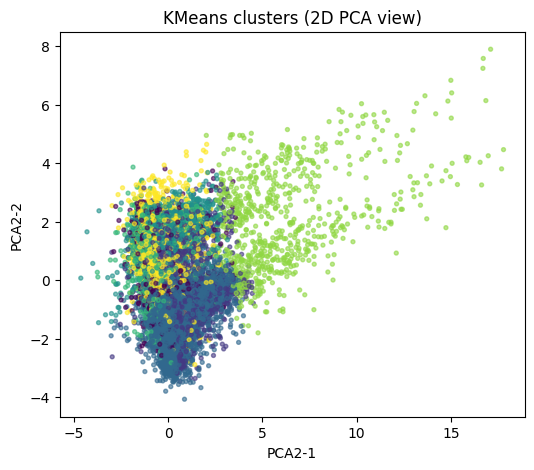

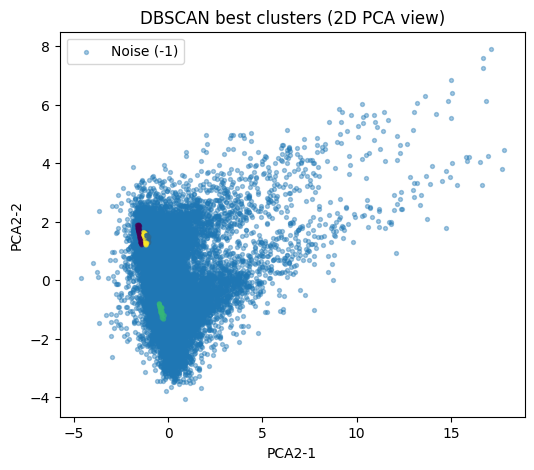

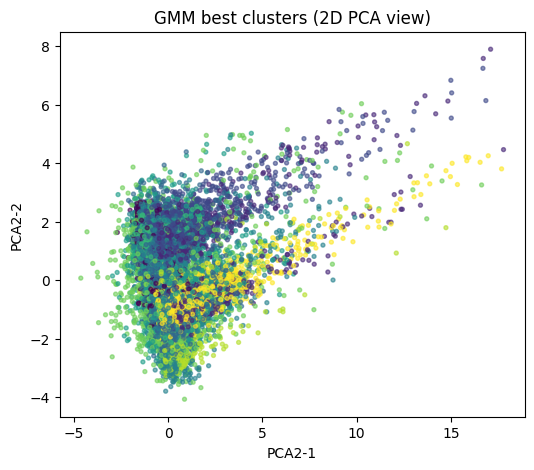

In [29]:
plot_clusters_2d(X_2d, labels_kmeans, "KMeans clusters (2D PCA view)")
plot_clusters_2d(X_2d, labels_db_best, "DBSCAN best clusters (2D PCA view)")
plot_clusters_2d(X_2d, labels_gmm_best, "GMM best clusters (2D PCA view)")


## Finalna tabela poređenja (najbolje verzije)

In [30]:
final_rows = []

final_rows.append({
    "Algorithm": f"KMeans (k={best_k_kmeans})",
    "silhouette": clustering_metrics(X_std_pca, labels_kmeans)[0],
    "davies_bouldin": clustering_metrics(X_std_pca, labels_kmeans)[1],
    "calinski_harabasz": clustering_metrics(X_std_pca, labels_kmeans)[2],
})

best_link = agg_results.iloc[0]["linkage"]
labels_agg_best = AgglomerativeClustering(n_clusters=2, linkage=best_link).fit_predict(X_std_pca)
final_rows.append({
    "Algorithm": f"Agglomerative ({best_link})",
    "silhouette": clustering_metrics(X_std_pca, labels_agg_best)[0],
    "davies_bouldin": clustering_metrics(X_std_pca, labels_agg_best)[1],
    "calinski_harabasz": clustering_metrics(X_std_pca, labels_agg_best)[2],
})

final_rows.append({
    "Algorithm": f"DBSCAN (eps={best_eps}, ms={best_ms})",
    "silhouette": clustering_metrics(X_std_pca, labels_db_best)[0],
    "davies_bouldin": clustering_metrics(X_std_pca, labels_db_best)[1],
    "calinski_harabasz": clustering_metrics(X_std_pca, labels_db_best)[2],
})

final_rows.append({
    "Algorithm": f"GMM (k={best_k_gmm}, cov={best_cov})",
    "silhouette": clustering_metrics(X_std_pca, labels_gmm_best)[0],
    "davies_bouldin": clustering_metrics(X_std_pca, labels_gmm_best)[1],
    "calinski_harabasz": clustering_metrics(X_std_pca, labels_gmm_best)[2],
    "AIC": gmm_best.aic(X_std_pca),
    "BIC": gmm_best.bic(X_std_pca),
})

pd.DataFrame(final_rows)


,Algorithm,silhouette,davies_bouldin,calinski_harabasz,AIC,BIC
0,KMeans (k=7),0.078345,2.705209,1214.596456,NaN,NaN
1,Agglomerative (average),0.696636,0.625819,226.916101,NaN,NaN
2,"DBSCAN (eps=0.3, ms=15)",0.891800,0.156728,3218.530669,NaN,NaN
3,"GMM (k=10, cov=full)",0.011384,4.313203,656.451690,-623800.19814,-594679.349882


## Linearna regresija (predikcija Amount)

In [31]:
X_lin = df_sample.drop(columns=["Amount", "Class"]).copy()
y_lin = df_sample["Amount"].copy()

print("X_lin shape:", X_lin.shape, "y_lin shape:", y_lin.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_lin, y_lin, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

lin_model = LinearRegression()
lin_model.fit(X_train_sc, y_train)

y_pred = lin_model.predict(X_test_sc)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression results:")
print("RMSE:", rmse)
print("R^2:", r2)


X_lin shape: (30000, 29) y_lin shape: (30000,)
Linear Regression results:
RMSE: 70.38681827340967
R^2: 0.9057788016194523


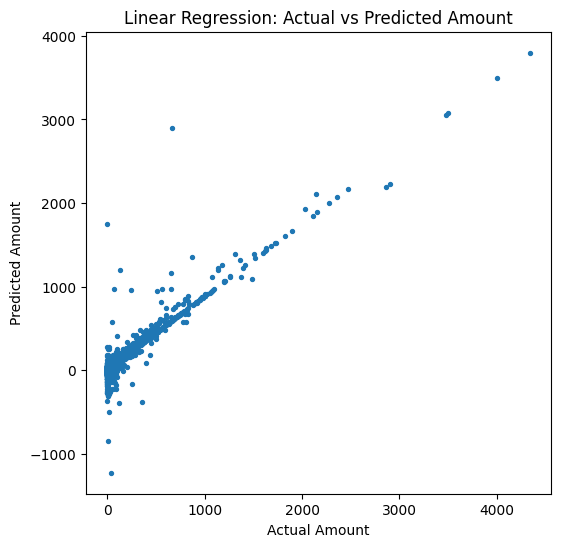

In [32]:
idx = np.random.RandomState(42).choice(len(y_test), size=min(5000, len(y_test)), replace=False)

plt.figure(figsize=(6,6))
plt.scatter(y_test.iloc[idx], y_pred[idx], s=8)
plt.title("Linear Regression: Actual vs Predicted Amount")
plt.xlabel("Actual Amount")
plt.ylabel("Predicted Amount")
plt.show()


## Logistička regresija (predikcija Class)

In [33]:
X_clf = df_sample.drop(columns=["Class"]).copy()
y_clf = df_sample["Class"].copy()

print("X_clf shape:", X_clf.shape, "y_clf shape:", y_clf.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
log_model.fit(X_train_sc, y_train)

y_pred = log_model.predict(X_test_sc)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))


X_clf shape: (30000, 30) y_clf shape: (30000,)
Accuracy: 0.9888333333333333

Confusion matrix:
 [[5927   64]
 [   3    6]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      5991
           1       0.09      0.67      0.15         9

    accuracy                           0.99      6000
   macro avg       0.54      0.83      0.57      6000
weighted avg       1.00      0.99      0.99      6000



## Konfuziona matrica (plot)

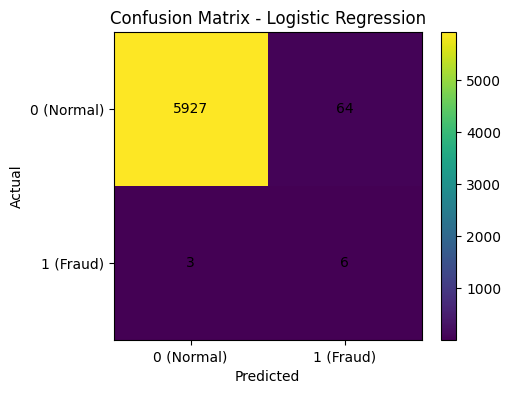

In [34]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["0 (Normal)", "1 (Fraud)"])
plt.yticks([0,1], ["0 (Normal)", "1 (Fraud)"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()


## ROC kriva + AUC

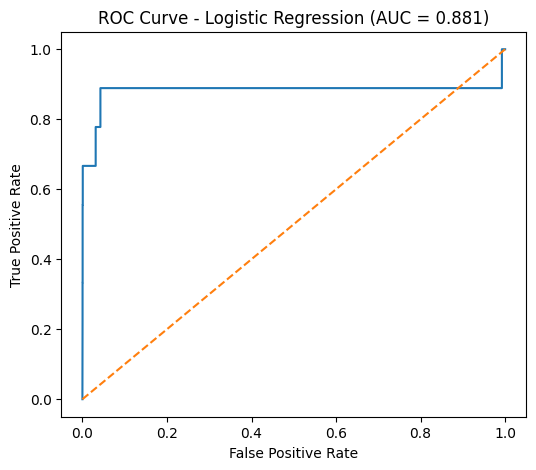

In [35]:
y_proba = log_model.predict_proba(X_test_sc)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.title(f"ROC Curve - Logistic Regression (AUC = {auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


## Precision–Recall kriva

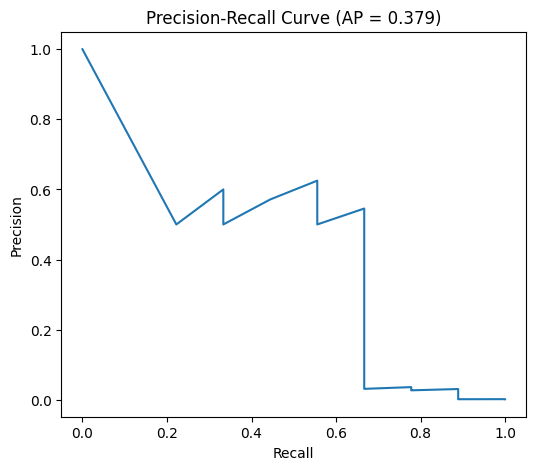

In [36]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.title(f"Precision-Recall Curve (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()
